# 09: X4 — DFN with Chen2020-specific frequency grid

## Goal

Replicate v0.1's 30-case DC-AC superimposed charging batch using **DFN** model 
on Chen2020, with the AC frequency grid recomputed from **Chen2020-specific τ**
(τ_Chen = 23.83 s, from HPPC SOC=20% charge in 07_hppc_chen2020.ipynb stage 2).

This isolates Hypothesis 2 (frequency-mismatch): if Chen2020 has its own intrinsic
τ ≠ MJ1's, MJ1-derived frequency grid mis-targets Chen2020's polarization timescale.

## Why

X2 (notebook 08) showed:
- DFN vs SPMe: 87% sign agreement (model order doesn't change AC predictions much)
- DFN vs MJ1 exp: 47.8% (close to chance)
- SPMe vs MJ1 exp: 52.2% (matches v0.1's reported ~48%)
→ Hypothesis 1 (SPMe lacks AC mechanism) NOT supported

X4 isolates the second variable: frequency grid.

## Methodology

τ_Chen = 23.83 s (HPPC SOC=20% charge tau2_60s, apples-to-apples to MJ1's τ=11.1s)

Frequency grid scaling: f_X4 = f_v0.1 × (11.1 / 23.83) = f_v0.1 × 0.4666

Each (DC, AC, τ-multiple) case from v0.1 is re-simulated with the rescaled f_Hz.
Same protocol, same model (DFN + lumped thermal), same Chen2020 parameters.

## Expected outcome categories

- **If X4 sign-agreement >> 50%**: Hypothesis 2 supported (frequency-mismatch was the issue)
- **If X4 sign-agreement ≈ 50%**: Frequency tuning insufficient; remaining gap is cell-parameter-mismatch (Hypothesis 3, deferred)
- **If X4 sign-agreement < X2's 47.8%**: Frequency mismatch was actually masking AC effects on Chen2020 — surprising result

## Deliverable

- 30 X4 cases batch run (~3 min wall-clock)
- 4-way Δt(Q80) comparison: X4 (DFN+Chen2020-freq) vs X2 (DFN+MJ1-freq) vs v0.1 (SPMe+MJ1-freq) vs MJ1 exp
- Sign-agreement matrix
- Δt(Q80) shape vs frequency plot (replication of MJ1 paper Figure 1?)

In [1]:
# ============================================================
# Cell 2: Imports + run_single_case_DFN (re-defined here for notebook independence)
# Note: identical to X2's run_single_case_DFN. Defined locally so notebook 09 
# is standalone (doesn't depend on notebook 08 kernel state).
# ============================================================
import pybamm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
import time
import json

print(f"PyBaMM version: {pybamm.__version__}")
print(f"NumPy version:  {np.__version__}")


def run_single_case_DFN(
    I_DC_Crate: float,
    A_Crate: float,
    f_Hz: float,
    parameter_set: str = "Chen2020",
    T_ambient_C: float = 20.0,
    nominal_capacity_Ah: float = 5.0,
    t_phase2_start_s: float = 8118.5,
    verbose: bool = False,
) -> dict:
    """DFN version. Identical schema to v0.1 SPMe run_single_case."""
    
    if A_Crate is None or (isinstance(A_Crate, float) and np.isnan(A_Crate)):
        A_Crate = 0.0
    if f_Hz is None or (isinstance(f_Hz, float) and np.isnan(f_Hz)):
        f_Hz = 0.0
    
    I_DC_A = -abs(I_DC_Crate) * nominal_capacity_Ah
    A_A    = A_Crate * nominal_capacity_Ah
    kappa  = (A_Crate / abs(I_DC_Crate)) if abs(I_DC_Crate) > 1e-9 else 0.0
    
    if A_Crate < 1e-9:
        case_id = f"DC{abs(I_DC_Crate):.2f}C_baseline"
    else:
        case_id = f"DC{abs(I_DC_Crate):.2f}C+AC{A_Crate:.2f}C_f{f_Hz:.5f}Hz"
    
    def dc_ac_current(variables):
        t_absolute = variables["Time [s]"]
        t_relative = t_absolute - t_phase2_start_s
        return I_DC_A + A_A * pybamm.sin(2 * np.pi * f_Hz * t_relative)
    
    dcac_step = pybamm.step.CustomStepExplicit(
        dc_ac_current, termination="4.2V", direction="charge",
        description=f"Phase 2: {case_id}",
    )
    experiment = pybamm.Experiment([
        "Discharge at 1C until 2.5V",
        "Hold at 2.5V until C/136",
        "Rest for 3805 seconds",
        dcac_step,
        "Hold at 4.2V until C/68",
    ])
    
    model = pybamm.lithium_ion.DFN(options={"thermal": "lumped"})
    pv = pybamm.ParameterValues(parameter_set)
    pv["Ambient temperature [K]"] = T_ambient_C + 273.15
    pv["Initial temperature [K]"] = T_ambient_C + 273.15
    
    sim = pybamm.Simulation(model, parameter_values=pv, experiment=experiment)
    
    t_start = time.time()
    try:
        solution = sim.solve()
    except Exception as e:
        return {
            "case_id": case_id, "I_DC_Crate": abs(I_DC_Crate), "A_Crate": A_Crate, "f_Hz": f_Hz,
            "kappa": kappa, "wall_clock_s": time.time() - t_start,
            "status": f"FAILED_SOLVE: {type(e).__name__}: {e}",
        }
    wall_clock_s = time.time() - t_start
    
    n_cycles = len(solution.cycles)
    base_dict = {
        "case_id": case_id, "I_DC_Crate": abs(I_DC_Crate), "A_Crate": A_Crate, "f_Hz": f_Hz,
        "kappa": kappa, "wall_clock_s": wall_clock_s,
    }
    
    if n_cycles < 4:
        return {**base_dict, "status": f"INFEASIBLE_EARLY: only {n_cycles} cycles completed"}
    
    if n_cycles < 5:
        phase2_partial = solution.cycles[3]
        cc_time_partial_s = phase2_partial.t[-1] - phase2_partial.t[0]
        T_max_partial = float(phase2_partial["X-averaged cell temperature [K]"].entries.max() - 273.15)
        V_min_phase2 = float(phase2_partial["Terminal voltage [V]"].entries.min())
        if verbose:
            print(f"  [{case_id}] INFEASIBLE: V_min={V_min_phase2:.3f}V")
        return {
            **base_dict,
            "status": f"INFEASIBLE_MIN_V: V_min={V_min_phase2:.3f}V in Phase 2",
            "CC_time_s_partial": cc_time_partial_s,
            "T_max_charging_C_partial": T_max_partial,
            "V_min_phase2": V_min_phase2,
        }
    
    phase2 = solution.cycles[3]
    phase3 = solution.cycles[4]
    
    cc_time_s = phase2.t[-1] - phase2.t[0]
    cv_time_s = phase3.t[-1] - phase3.t[0]
    total_time_s = cc_time_s + cv_time_s
    
    t_chg = np.concatenate([phase2.t, phase3.t])
    I_chg = np.concatenate([phase2["Current [A]"].entries, phase3["Current [A]"].entries])
    _, unique_idx = np.unique(t_chg, return_index=True)
    unique_idx_sorted = np.sort(unique_idx)
    t_chg = t_chg[unique_idx_sorted]
    I_chg = I_chg[unique_idx_sorted]
    t_chg = t_chg - t_chg[0]
    
    Q_net_As = -cumulative_trapezoid(I_chg, t_chg, initial=0)
    Q_net_mAh = Q_net_As / 3600.0 * 1000.0
    Q_final_mAh = float(Q_net_mAh[-1])
    
    dQ = np.diff(Q_net_mAh)
    n_decreases = int(np.sum(dQ < 0))
    pct_decreases = 100.0 * n_decreases / max(len(dQ), 1)
    
    T_max_p2 = float(phase2["X-averaged cell temperature [K]"].entries.max() - 273.15)
    T_max_p3 = float(phase3["X-averaged cell temperature [K]"].entries.max() - 273.15)
    T_max_charging = max(T_max_p2, T_max_p3)
    
    if verbose:
        print(f"  [{case_id}] CC={cc_time_s/60:.2f}min T_max={T_max_charging:.2f}°C "
              f"Q={Q_final_mAh:.0f}mAh wall={wall_clock_s:.2f}s")
    
    return {
        **base_dict,
        "CC_time_s": cc_time_s, "CV_time_s": cv_time_s, "total_time_s": total_time_s,
        "CC_time_min": cc_time_s/60, "CV_time_min": cv_time_s/60, "total_time_min": total_time_s/60,
        "Q_net_final_mAh": Q_final_mAh,
        "Q_net_trajectory": Q_net_mAh.tolist(),
        "t_chg": t_chg.tolist(),
        "I_chg": I_chg.tolist(),
        "T_max_charging_C": T_max_charging,
        "n_AC_reversals_steps": n_decreases,
        "pct_AC_reversals": pct_decreases,
        "status": "ok",
    }

print("✓ run_single_case_DFN defined.")

PyBaMM version: 26.3.1
NumPy version:  2.4.4
✓ run_single_case_DFN defined.


In [2]:
# ============================================================
# Cell 3: Build X4 cases list — Chen2020-specific frequency grid
# τ_Chen = 23.83 s (HPPC SOC=20% charge tau2_60s, from notebook 07 stage 2)
# Frequency rescale: f_X4 = f_v0.1 × (11.1 / 23.83) = f_v0.1 × 0.4666
# ============================================================

# === Reference values ===
TAU_MJ1 = 11.1     # s, MJ1 reference (your JES1 paper)
TAU_CHEN = 23.83   # s, Chen2020 SOC=20% charge tau2_60s (apples-to-apples)
FREQ_RESCALE = TAU_MJ1 / TAU_CHEN
print(f"τ_MJ1 = {TAU_MJ1} s")
print(f"τ_Chen = {TAU_CHEN} s (HPPC SOC=20% charge, apples-to-apples vs MJ1)")
print(f"Frequency rescale factor: f_X4 / f_v0.1 = {FREQ_RESCALE:.4f}")

# === Load v0.1 cases from JSON (precise frequencies, includes baselines) ===
with open("../data/results_day6_batch_scan.json", "r") as f:
    v01_json = json.load(f)

# Extract precise (DC, AC, f_v0.1) and rescale f
import re
cases_x4 = []
for entry in v01_json:
    cid = entry["case_id"]
    
    if "_baseline" in cid:
        # Baselines: keep as is (no AC, f_Hz=0)
        m = re.match(r"DC([\d.]+)C_baseline", cid)
        if m:
            cases_x4.append({
                "condition": entry.get("condition_label", cid),
                "I_DC_C": float(m.group(1)),
                "A_C": 0.0,
                "f_Hz_v01": 0.0,
                "f_Hz_X4": 0.0,
                "tau_label": "baseline",
            })
    else:
        m = re.match(r"DC([\d.]+)C\+AC([\d.]+)C_f([\d.]+)Hz", cid)
        if m:
            DC = float(m.group(1))
            AC = float(m.group(2))
            f_v01 = float(m.group(3))
            f_X4 = f_v01 * FREQ_RESCALE   # rescale frequency to Chen2020 timescale
            cases_x4.append({
                "condition": entry.get("condition_label", cid),
                "I_DC_C": DC,
                "A_C": AC,
                "f_Hz_v01": f_v01,
                "f_Hz_X4": f_X4,
                "tau_label": entry.get("condition_label", "").split()[-1],
            })

# Add the v0.1 missing infeasible case
cases_x4.append({
    "condition": "0.2+0.8C 10τ",
    "I_DC_C": 0.2,
    "A_C": 0.8,
    "f_Hz_v01": 0.00143,
    "f_Hz_X4": 0.00143 * FREQ_RESCALE,
    "tau_label": "10τ",
})

df_cases_x4 = pd.DataFrame(cases_x4)
print(f"\nX4 cases: {len(df_cases_x4)} total")
print(f"\nFrequency mapping (v0.1 → X4):")
display_cols_freq = ["condition", "I_DC_C", "A_C", "tau_label", "f_Hz_v01", "f_Hz_X4"]
df_unique_freqs = df_cases_x4[display_cols_freq].drop_duplicates(subset=["tau_label", "f_Hz_v01"])
with pd.option_context('display.float_format', '{:.5f}'.format,
                        'display.width', 200, 'display.max_columns', 10):
    print(df_unique_freqs.sort_values("f_Hz_v01").to_string(index=False))

τ_MJ1 = 11.1 s
τ_Chen = 23.83 s (HPPC SOC=20% charge, apples-to-apples vs MJ1)
Frequency rescale factor: f_X4 / f_v0.1 = 0.4658

X4 cases: 31 total

Frequency mapping (v0.1 → X4):
     condition  I_DC_C     A_C tau_label  f_Hz_v01  f_Hz_X4
       0.1C_DC 0.10000 0.00000  baseline   0.00000  0.00000
0.2+0.3C 34.8τ 0.20000 0.30000     34.8τ   0.00041  0.00019
0.9+0.1C 16.7τ 0.90000 0.10000     16.7τ   0.00086  0.00040
  0.2+0.3C 10τ 0.20000 0.30000       10τ   0.00143  0.00067
   0.4+0.6C 5τ 0.40000 0.60000        5τ   0.00286  0.00133
0.4+0.5C 1.67τ 0.40000 0.50000     1.67τ   0.00860  0.00401
   0.1+0.9C 1τ 0.10000 0.90000        1τ   0.01430  0.00666
 0.4+0.6C 0.5τ 0.40000 0.60000      0.5τ   0.02860  0.01332
 0.2+0.8C 0.1τ 0.20000 0.80000      0.1τ   0.14300  0.06661


In [3]:
# ============================================================
# Cell 3b: Add Round 3 (τ=19.72s, charge min) to X4 cases
# Total batch: Round 1 (τ=23.83s) + Round 3 (τ=19.72s) = 62 cases
# ============================================================

# τ_Chen Round 3: charge-direction min from notebook 07 stage 2
# SOC=10% charge tau2_60s = 19.72 s (lowest charge τ across all 10 SOCs)
TAU_CHEN_R1 = 23.83   # SOC=20% charge single point (apples-to-apples)
TAU_CHEN_R3 = 19.72   # all-SOC charge min (lower-bound sensitivity check)

FREQ_RESCALE_R1 = TAU_MJ1 / TAU_CHEN_R1   # = 0.4658
FREQ_RESCALE_R3 = TAU_MJ1 / TAU_CHEN_R3   # = 0.5629

print(f"Round 1: τ_Chen = {TAU_CHEN_R1} s, rescale = {FREQ_RESCALE_R1:.4f}")
print(f"Round 3: τ_Chen = {TAU_CHEN_R3} s, rescale = {FREQ_RESCALE_R3:.4f}")
print(f"Frequency difference Round 1 vs Round 3: {(FREQ_RESCALE_R3/FREQ_RESCALE_R1 - 1)*100:+.1f}%")

# Build Round 3 cases (same structure as Round 1, different rescale)
cases_x4_R3 = []
for entry in v01_json:
    cid = entry["case_id"]
    if "_baseline" in cid:
        m = re.match(r"DC([\d.]+)C_baseline", cid)
        if m:
            cases_x4_R3.append({
                "condition": entry.get("condition_label", cid),
                "I_DC_C": float(m.group(1)),
                "A_C": 0.0,
                "f_Hz_v01": 0.0,
                "f_Hz_X4": 0.0,
                "tau_label": "baseline",
                "round": "R3",
                "tau_Chen_s": TAU_CHEN_R3,
            })
    else:
        m = re.match(r"DC([\d.]+)C\+AC([\d.]+)C_f([\d.]+)Hz", cid)
        if m:
            DC = float(m.group(1))
            AC = float(m.group(2))
            f_v01 = float(m.group(3))
            cases_x4_R3.append({
                "condition": entry.get("condition_label", cid),
                "I_DC_C": DC,
                "A_C": AC,
                "f_Hz_v01": f_v01,
                "f_Hz_X4": f_v01 * FREQ_RESCALE_R3,
                "tau_label": entry.get("condition_label", "").split()[-1],
                "round": "R3",
                "tau_Chen_s": TAU_CHEN_R3,
            })

# Add infeasible case
cases_x4_R3.append({
    "condition": "0.2+0.8C 10τ",
    "I_DC_C": 0.2,
    "A_C": 0.8,
    "f_Hz_v01": 0.00143,
    "f_Hz_X4": 0.00143 * FREQ_RESCALE_R3,
    "tau_label": "10τ",
    "round": "R3",
    "tau_Chen_s": TAU_CHEN_R3,
})

# Tag Round 1 cases
for c in cases_x4:
    c["round"] = "R1"
    c["tau_Chen_s"] = TAU_CHEN_R1

# Combine
cases_x4_all = cases_x4 + cases_x4_R3
df_cases_all = pd.DataFrame(cases_x4_all)
print(f"\nTotal cases (R1 + R3): {len(df_cases_all)}")
print(f"  Round 1 (τ={TAU_CHEN_R1}s): {sum(c['round'] == 'R1' for c in cases_x4_all)} cases")
print(f"  Round 3 (τ={TAU_CHEN_R3}s): {sum(c['round'] == 'R3' for c in cases_x4_all)} cases")

print(f"\nFrequency mapping side-by-side:")
unique_tau_labels = ["0.1τ", "0.5τ", "1τ", "1.67τ", "5τ", "10τ", "16.7τ", "34.8τ"]
print(f"{'τ_label':<8} {'f_v01 (Hz)':>12} {'f_X4_R1 (Hz)':>14} {'f_X4_R3 (Hz)':>14}")
print("-" * 50)
for tau_lbl in unique_tau_labels:
    r1_match = [c for c in cases_x4 if c["tau_label"] == tau_lbl and c["A_C"] > 0]
    r3_match = [c for c in cases_x4_R3 if c["tau_label"] == tau_lbl and c["A_C"] > 0]
    if r1_match and r3_match:
        f_v01 = r1_match[0]["f_Hz_v01"]
        f_r1 = r1_match[0]["f_Hz_X4"]
        f_r3 = r3_match[0]["f_Hz_X4"]
        print(f"{tau_lbl:<8} {f_v01:>12.5f} {f_r1:>14.5f} {f_r3:>14.5f}")

Round 1: τ_Chen = 23.83 s, rescale = 0.4658
Round 3: τ_Chen = 19.72 s, rescale = 0.5629
Frequency difference Round 1 vs Round 3: +20.8%

Total cases (R1 + R3): 62
  Round 1 (τ=23.83s): 31 cases
  Round 3 (τ=19.72s): 31 cases

Frequency mapping side-by-side:
τ_label    f_v01 (Hz)   f_X4_R1 (Hz)   f_X4_R3 (Hz)
--------------------------------------------------
0.1τ          0.14300        0.06661        0.08049
0.5τ          0.02860        0.01332        0.01610
1τ            0.01430        0.00666        0.00805
1.67τ         0.00860        0.00401        0.00484
5τ            0.00286        0.00133        0.00161
10τ           0.00143        0.00067        0.00080
16.7τ         0.00086        0.00040        0.00048
34.8τ         0.00041        0.00019        0.00023


In [4]:
# ============================================================
# Cell 4: Run X4 batch — R1 (τ=23.83s) + R3 (τ=19.72s) = 62 cases
# ============================================================

print(f"X4 batch: {len(cases_x4_all)} total cases (R1 + R3)")
print("=" * 70)
print(f"Estimated wall-clock: ~6 min")
print("=" * 70)

x4_results = []
batch_t_start = time.time()
n_ok = {"R1": 0, "R3": 0}
n_infeas = {"R1": 0, "R3": 0}
n_fail = {"R1": 0, "R3": 0}

for i, case in enumerate(cases_x4_all):
    rnd = case["round"]
    cond = case["condition"]
    DC = case["I_DC_C"]
    A = case["A_C"]
    f = case["f_Hz_X4"]
    
    print(f"[{i+1:2d}/{len(cases_x4_all)}] [{rnd}] {cond:20s} (DC={DC:.2f}, AC={A:.2f}, f={f:.5f}Hz)... ",
          end="", flush=True)
    
    r = run_single_case_DFN(
        I_DC_Crate=DC, A_Crate=A, f_Hz=f,
        parameter_set="Chen2020", T_ambient_C=20.0,
        nominal_capacity_Ah=5.0, t_phase2_start_s=8118.5,
        verbose=False,
    )
    r["condition"] = cond
    r["tau_label"] = case["tau_label"]
    r["round"] = rnd
    r["tau_Chen_s"] = case["tau_Chen_s"]
    r["f_Hz_v01"] = case["f_Hz_v01"]   # keep original v0.1 frequency for cross-ref
    x4_results.append(r)
    
    if r["status"] == "ok":
        n_ok[rnd] += 1
        print(f"✓ CC={r['CC_time_min']:.1f}m T={r['T_max_charging_C']:.1f}°C "
              f"Q={r['Q_net_final_mAh']:.0f}mAh ({r['wall_clock_s']:.1f}s)")
    elif "INFEASIBLE" in r["status"]:
        n_infeas[rnd] += 1
        print(f"⊘ INFEASIBLE ({r['wall_clock_s']:.1f}s)")
    else:
        n_fail[rnd] += 1
        print(f"✗ FAILED: {r['status']}")

batch_total = time.time() - batch_t_start
print("\n" + "=" * 70)
print(f"X4 batch complete:")
print(f"  Round 1 (τ=23.83s): {n_ok['R1']} ok, {n_infeas['R1']} infeasible, {n_fail['R1']} failed")
print(f"  Round 3 (τ=19.72s): {n_ok['R3']} ok, {n_infeas['R3']} infeasible, {n_fail['R3']} failed")
print(f"Total wall-clock: {batch_total:.1f}s ({batch_total/len(cases_x4_all):.2f} s/case)")
print("=" * 70)

# Save
df_x4 = pd.DataFrame(x4_results)
df_x4_csv = df_x4.drop(columns=[c for c in ["Q_net_trajectory", "t_chg", "I_chg"] if c in df_x4.columns])
df_x4_csv.to_csv("../data/results_day8_x4_dfn_chenfreq.csv", index=False)
with open("../data/results_day8_x4_dfn_chenfreq.json", "w") as f:
    json.dump(x4_results, f, default=str)
print(f"\nSaved CSV: ../data/results_day8_x4_dfn_chenfreq.csv")
print(f"Saved JSON: ../data/results_day8_x4_dfn_chenfreq.json")

X4 batch: 62 total cases (R1 + R3)
Estimated wall-clock: ~6 min
[ 1/62] [R1] 0.1+0.9C 1τ          (DC=0.10, AC=0.90, f=0.00666Hz)... ✓ CC=487.4m T=27.0°C Q=5129mAh (5.6s)
[ 2/62] [R1] 0.1+0.2C 1τ          (DC=0.10, AC=0.20, f=0.00666Hz)... ✓ CC=582.3m T=20.8°C Q=5128mAh (2.7s)
[ 3/62] [R1] 0.2+0.3C 1τ          (DC=0.20, AC=0.30, f=0.00666Hz)... ✓ CC=274.6m T=22.0°C Q=5127mAh (2.3s)
[ 4/62] [R1] 0.2+0.3C 10τ         (DC=0.20, AC=0.30, f=0.00067Hz)... ✓ CC=269.6m T=22.6°C Q=5129mAh (1.1s)
[ 5/62] [R1] 0.2+0.3C 34.8τ       (DC=0.20, AC=0.30, f=0.00019Hz)... ✓ CC=314.7m T=23.9°C Q=5128mAh (1.1s)
[ 6/62] [R1] 0.2+0.8C 0.1τ        (DC=0.20, AC=0.80, f=0.06661Hz)... ✓ CC=248.6m T=25.3°C Q=5123mAh (28.6s)
[ 7/62] [R1] 0.2+0.8C 1τ          (DC=0.20, AC=0.80, f=0.00666Hz)... ✓ CC=239.7m T=25.9°C Q=5126mAh (3.3s)
[ 8/62] [R1] 0.2+0.8C 10τ         (DC=0.20, AC=0.80, f=0.00067Hz)... 

2026-04-27 12:48:11.502 - [WARNING] callbacks.on_experiment_infeasible_event(254): 

	Experiment is infeasible: 'event: Minimum voltage [V]' was triggered during 'Phase 2: DC0.20C+AC0.80C_f0.00067Hz'. The returned solution only contains up to step 1 of cycle 4. 


⊘ INFEASIBLE (0.8s)
[ 9/62] [R1] 0.3+0.7C 0.1τ        (DC=0.30, AC=0.70, f=0.06661Hz)... ✓ CC=162.3m T=25.1°C Q=5123mAh (16.5s)
[10/62] [R1] 0.3+0.7C 1τ          (DC=0.30, AC=0.70, f=0.00666Hz)... ✓ CC=157.1m T=25.7°C Q=5125mAh (2.3s)
[11/62] [R1] 0.3+0.7C 10τ         (DC=0.30, AC=0.70, f=0.00067Hz)... 

2026-04-27 12:48:31.187 - [WARNING] callbacks.on_experiment_infeasible_event(254): 

	Experiment is infeasible: 'event: Minimum voltage [V]' was triggered during 'Phase 2: DC0.30C+AC0.70C_f0.00067Hz'. The returned solution only contains up to step 1 of cycle 4. 


⊘ INFEASIBLE (0.8s)
[12/62] [R1] 0.3+0.4C 0.1τ        (DC=0.30, AC=0.40, f=0.06661Hz)... ✓ CC=170.1m T=23.5°C Q=5126mAh (11.3s)
[13/62] [R1] 0.3+0.4C 1τ          (DC=0.30, AC=0.40, f=0.00666Hz)... ✓ CC=167.0m T=23.8°C Q=5126mAh (2.0s)
[14/62] [R1] 0.3+0.4C 10τ         (DC=0.30, AC=0.40, f=0.00067Hz)... ✓ CC=167.7m T=24.4°C Q=5126mAh (1.2s)
[15/62] [R1] 0.4+0.6C 0.5τ        (DC=0.40, AC=0.60, f=0.01332Hz)... ✓ CC=118.5m T=25.5°C Q=5124mAh (2.7s)
[16/62] [R1] 0.4+0.5C 1.67τ       (DC=0.40, AC=0.50, f=0.00401Hz)... ✓ CC=119.4m T=25.2°C Q=5125mAh (1.5s)
[17/62] [R1] 0.4+0.6C 1.67τ       (DC=0.40, AC=0.60, f=0.00401Hz)... ✓ CC=115.5m T=26.1°C Q=5126mAh (1.4s)
[18/62] [R1] 0.4+0.6C 5τ          (DC=0.40, AC=0.60, f=0.00133Hz)... ✓ CC=120.8m T=26.6°C Q=5126mAh (1.2s)
[19/62] [R1] 0.4+0.6C 10τ         (DC=0.40, AC=0.60, f=0.00067Hz)... ✓ CC=118.0m T=27.8°C Q=5125mAh (1.1s)
[20/62] [R1] 0.5+0.5C 1τ          (DC=0.50, AC=0.50, f=0.00666Hz)... ✓ CC=91.9m T=26.4°C Q=5126mAh (1.6s)
[21/62] [R1] 0.9+

...

⊘ INFEASIBLE (0.9s)
[40/62] [R3] 0.3+0.7C 0.1τ        (DC=0.30, AC=0.70, f=0.08049Hz)... ✓ CC=162.5m T=25.1°C Q=5124mAh (19.9s)
[41/62] [R3] 0.3+0.7C 1τ          (DC=0.30, AC=0.70, f=0.00805Hz)... ✓ CC=158.9m T=25.5°C Q=5124mAh (2.7s)
[42/62] [R3] 0.3+0.7C 10τ         (DC=0.30, AC=0.70, f=0.00080Hz)... 

2026-04-27 12:50:26.594 - [WARNING] callbacks.on_experiment_infeasible_event(254): 

	Experiment is infeasible: 'event: Minimum voltage [V]' was triggered during 'Phase 2: DC0.30C+AC0.70C_f0.00080Hz'. The returned solution only contains up to step 1 of cycle 4. 


⊘ INFEASIBLE (0.8s)
[43/62] [R3] 0.3+0.4C 0.1τ        (DC=0.30, AC=0.40, f=0.08049Hz)... ✓ CC=169.9m T=23.5°C Q=5125mAh (13.7s)
[44/62] [R3] 0.3+0.4C 1τ          (DC=0.30, AC=0.40, f=0.00805Hz)... ✓ CC=167.2m T=23.7°C Q=5126mAh (2.1s)
[45/62] [R3] 0.3+0.4C 10τ         (DC=0.30, AC=0.40, f=0.00080Hz)... ✓ CC=178.4m T=24.3°C Q=5126mAh (1.2s)
[46/62] [R3] 0.4+0.6C 0.5τ        (DC=0.40, AC=0.60, f=0.01610Hz)... ✓ CC=118.8m T=25.5°C Q=5124mAh (3.3s)
[47/62] [R3] 0.4+0.5C 1.67τ       (DC=0.40, AC=0.50, f=0.00484Hz)... ✓ CC=119.5m T=25.2°C Q=5125mAh (1.6s)
[48/62] [R3] 0.4+0.6C 1.67τ       (DC=0.40, AC=0.60, f=0.00484Hz)... ✓ CC=116.2m T=26.0°C Q=5126mAh (1.5s)
[49/62] [R3] 0.4+0.6C 5τ          (DC=0.40, AC=0.60, f=0.00161Hz)... ✓ CC=120.7m T=26.4°C Q=5126mAh (1.2s)
[50/62] [R3] 0.4+0.6C 10τ         (DC=0.40, AC=0.60, f=0.00080Hz)... ✓ CC=118.1m T=27.4°C Q=5125mAh (1.1s)
[51/62] [R3] 0.5+0.5C 1τ          (DC=0.50, AC=0.50, f=0.00805Hz)... ✓ CC=92.6m T=26.2°C Q=5125mAh (1.7s)
[52/62] [R3] 0.9+

2026-04-27 12:51:06.148 - [WARNING] callbacks.on_experiment_infeasible_event(254): 

	Experiment is infeasible: 'event: Minimum voltage [V]' was triggered during 'Phase 2: DC0.20C+AC0.80C_f0.00080Hz'. The returned solution only contains up to step 1 of cycle 4. 


⊘ INFEASIBLE (0.8s)

X4 batch complete:
  Round 1 (τ=23.83s): 28 ok, 3 infeasible, 0 failed
  Round 3 (τ=19.72s): 28 ok, 3 infeasible, 0 failed
Total wall-clock: 220.6s (3.56 s/case)

Saved CSV: ../data/results_day8_x4_dfn_chenfreq.csv
Saved JSON: ../data/results_day8_x4_dfn_chenfreq.json


In [5]:
# ============================================================
# Cell 5: 5-way Δt(Q80) comparison + sign-agreement matrix
# X4-R1 vs X4-R3 vs X2 (DFN MJ1-freq) vs v0.1 (SPMe MJ1-freq) vs MJ1 exp
# ============================================================

# Load X2 data (DFN + MJ1 freq)
with open("../data/results_day8_x2_dfn_mj1freq_v2.json", "r") as f:
    x2_results = json.load(f)
df_v01_csv = pd.read_csv("../data/results_day6_summary.csv")

# Helper: Δt(Q80) with linear interpolation (same as X2 Cell 14 fix)
def compute_dt_at_Q_interp(t_chg, Q_net_mAh, t_chg_baseline, Q_net_baseline_mAh, Q_target_mAh):
    def first_passage_interp(t, Q):
        t = np.asarray(t, dtype=float)
        Q = np.asarray(Q, dtype=float)
        idx = np.where(Q >= Q_target_mAh)[0]
        if len(idx) == 0:
            return np.nan
        i = int(idx[0])
        if i == 0:
            return float(t[0])
        Q_lo, Q_hi = Q[i-1], Q[i]
        t_lo, t_hi = t[i-1], t[i]
        if Q_hi == Q_lo:
            return float(t_lo)
        frac = (Q_target_mAh - Q_lo) / (Q_hi - Q_lo)
        return float(t_lo + frac * (t_hi - t_lo))
    
    t_proto = first_passage_interp(t_chg, Q_net_mAh)
    t_base = first_passage_interp(t_chg_baseline, Q_net_baseline_mAh)
    if np.isnan(t_proto) or np.isnan(t_base):
        return np.nan
    return (t_base - t_proto) / 60.0  # minutes

Q80_TARGET = 0.80 * 5126.0  # 4101 mAh

# === Build baselines per source ===
def build_baselines(results, key_fn=lambda r: float(r["I_DC_Crate"])):
    baselines = {}
    for r in results:
        if isinstance(r.get("A_Crate"), str):
            r["A_Crate"] = float(r["A_Crate"])
        if r["A_Crate"] < 1e-9 and r.get("status") == "ok":
            traj = r.get("Q_net_trajectory")
            t = r.get("t_chg")
            if isinstance(traj, str):
                traj = json.loads(traj)
            if isinstance(t, str):
                t = json.loads(t)
            baselines[key_fn(r)] = (np.array(t), np.array(traj))
    return baselines

# X4-R1 baselines (only R1 baselines)
x4_R1_baselines = build_baselines(
    [r for r in x4_results if r.get("round") == "R1"]
)
x4_R3_baselines = build_baselines(
    [r for r in x4_results if r.get("round") == "R3"]
)

# X2 baselines (recall: x2_results loaded from JSON, so trajectories may be lists or strings)
def coerce_results(results):
    for r in results:
        for k in ["Q_net_trajectory", "t_chg", "I_chg"]:
            if k in r and isinstance(r[k], str):
                try:
                    r[k] = json.loads(r[k])
                except:
                    pass
        if "A_Crate" in r and isinstance(r["A_Crate"], str):
            r["A_Crate"] = float(r["A_Crate"])
        if "I_DC_Crate" in r and isinstance(r["I_DC_Crate"], str):
            r["I_DC_Crate"] = float(r["I_DC_Crate"])
        if "f_Hz" in r and isinstance(r["f_Hz"], str):
            r["f_Hz"] = float(r["f_Hz"])
    return results

x2_results = coerce_results(x2_results)
x2_baselines = build_baselines(x2_results)

# v0.1 baselines (already loaded in v01_json from Cell 3)
v01_baselines = build_baselines(v01_json)

print(f"Baselines available:")
print(f"  X4-R1: {sorted(x4_R1_baselines.keys())}")
print(f"  X4-R3: {sorted(x4_R3_baselines.keys())}")
print(f"  X2:    {sorted(x2_baselines.keys())}")
print(f"  v0.1:  {sorted(v01_baselines.keys())}")

# === Build 5-way comparison ===
def compute_dt_for_round(results, baselines):
    """Returns dict: case_key (DC, AC, tau_label) → Δt(Q80) min"""
    out = {}
    for r in results:
        if r["A_Crate"] < 1e-9 or r.get("status") != "ok":
            continue
        DC = float(r["I_DC_Crate"])
        AC = float(r["A_Crate"])
        tau_lbl = r.get("tau_label", "?")
        if DC not in baselines:
            continue
        t_base, Q_base = baselines[DC]
        traj = r["Q_net_trajectory"] if isinstance(r["Q_net_trajectory"], list) else json.loads(r["Q_net_trajectory"])
        t_arr = r["t_chg"] if isinstance(r["t_chg"], list) else json.loads(r["t_chg"])
        dt = compute_dt_at_Q_interp(np.array(t_arr), np.array(traj), t_base, Q_base, Q80_TARGET)
        key = (round(DC, 2), round(AC, 2), tau_lbl)
        out[key] = dt
    return out

# Compute Δt for each round
dt_x4_R1 = compute_dt_for_round([r for r in x4_results if r.get("round") == "R1"], x4_R1_baselines)
dt_x4_R3 = compute_dt_for_round([r for r in x4_results if r.get("round") == "R3"], x4_R3_baselines)
dt_x2 = compute_dt_for_round(x2_results, x2_baselines)
dt_v01 = compute_dt_for_round(v01_json, v01_baselines)

# Build comparison rows: anchor on R1 keys (tau_label distinguishes 16.7τ vs 10τ which collide on f_Hz)
comparison_rows = []
for r in x4_results:
    if r.get("round") != "R1":
        continue
    if r["A_Crate"] < 1e-9 or r.get("status") != "ok":
        continue
    DC = round(float(r["I_DC_Crate"]), 2)
    AC = round(float(r["A_Crate"]), 2)
    tau_lbl = r.get("tau_label", "?")
    cond = r["condition"]
    key = (DC, AC, tau_lbl)
    
    # Get Δt from each source (key may be missing in some sources due to infeasibility)
    dt_R1_v = dt_x4_R1.get(key, np.nan)
    dt_R3_v = dt_x4_R3.get(key, np.nan)
    dt_X2_v = dt_x2.get(key, np.nan)
    dt_v01_v = dt_v01.get(key, np.nan)
    
    # Δt exp from CSV
    dt_exp_v = np.nan
    csv_match = df_v01_csv[df_v01_csv["condition"] == cond]
    if len(csv_match) > 0 and pd.notna(csv_match["exp_Δt_Q80"].iloc[0]):
        dt_exp_v = float(csv_match["exp_Δt_Q80"].iloc[0])
    
    def sign(x):
        if np.isnan(x): return None
        if x > 0.05: return "+"
        if x < -0.05: return "-"
        return "0"
    
    s_R1 = sign(dt_R1_v)
    s_R3 = sign(dt_R3_v)
    s_X2 = sign(dt_X2_v)
    s_v01 = sign(dt_v01_v)
    s_exp = sign(dt_exp_v)
    
    comparison_rows.append({
        "condition": cond,
        "DC": DC, "AC": AC, "tau_label": tau_lbl, "kappa": AC/DC,
        "dt_R1": dt_R1_v,
        "dt_R3": dt_R3_v,
        "dt_X2": dt_X2_v,
        "dt_v01": dt_v01_v,
        "dt_exp": dt_exp_v,
        "s_R1": s_R1, "s_R3": s_R3, "s_X2": s_X2, "s_v01": s_v01, "s_exp": s_exp,
        "R1_vs_exp": (s_R1 == s_exp) if (s_R1 and s_exp) else None,
        "R3_vs_exp": (s_R3 == s_exp) if (s_R3 and s_exp) else None,
        "X2_vs_exp": (s_X2 == s_exp) if (s_X2 and s_exp) else None,
        "v01_vs_exp": (s_v01 == s_exp) if (s_v01 and s_exp) else None,
        "R1_vs_R3": (s_R1 == s_R3) if (s_R1 and s_R3) else None,
        "R1_vs_X2": (s_R1 == s_X2) if (s_R1 and s_X2) else None,
    })

df_5way = pd.DataFrame(comparison_rows)
display_cols = ["condition", "kappa", "tau_label",
                "dt_R1", "dt_R3", "dt_X2", "dt_v01", "dt_exp",
                "s_R1", "s_R3", "s_X2", "s_v01", "s_exp",
                "R1_vs_exp", "R3_vs_exp", "X2_vs_exp", "v01_vs_exp"]

print(f"\n=== 5-way Δt(Q80) comparison: {len(df_5way)} cases ===\n")
with pd.option_context('display.float_format', '{:+.3f}'.format,
                        'display.width', 280, 'display.max_columns', 30):
    print(df_5way[display_cols].to_string(index=False))

# === Sign-agreement statistics ===
print("\n" + "=" * 70)
print("Sign-agreement statistics (vs MJ1 exp)")
print("=" * 70)
def agreement_stats(df, col, label):
    valid = df[col].dropna()
    if len(valid) == 0:
        return f"  {label}: no valid"
    n_agree = int(valid.sum())
    n_valid = len(valid)
    return f"  {label}: {n_agree}/{n_valid} ({100*n_agree/n_valid:.1f}%)"

print(agreement_stats(df_5way, "R1_vs_exp", "X4-R1 (τ=23.83s) vs exp"))
print(agreement_stats(df_5way, "R3_vs_exp", "X4-R3 (τ=19.72s) vs exp"))
print(agreement_stats(df_5way, "X2_vs_exp", "X2 (DFN MJ1-freq)  vs exp [referenced from X2 = 47.8%]"))
print(agreement_stats(df_5way, "v01_vs_exp", "v0.1 (SPMe MJ1-freq) vs exp [referenced ≈ 52.2%]"))
print()
print(agreement_stats(df_5way, "R1_vs_R3", "X4-R1 vs X4-R3 (frequency sensitivity)"))
print(agreement_stats(df_5way, "R1_vs_X2", "X4-R1 vs X2 (Chen vs MJ1 freq)"))

# Save
df_5way.to_csv("../data/results_day8_x4_5way_dt_Q80.csv", index=False)
print(f"\nSaved: ../data/results_day8_x4_5way_dt_Q80.csv")

Baselines available:
  X4-R1: [0.1, 0.2, 0.3, 0.4, 0.5, 0.9]
  X4-R3: [0.1, 0.2, 0.3, 0.4, 0.5, 0.9]
  X2:    [0.1, 0.2, 0.3, 0.4, 0.5, 0.9]
  v0.1:  [0.1, 0.2, 0.3, 0.4, 0.5, 0.9]

=== 5-way Δt(Q80) comparison: 22 cases ===

     condition  kappa tau_label  dt_R1   dt_R3  dt_X2  dt_v01  dt_exp s_R1 s_R3 s_X2 s_v01 s_exp  R1_vs_exp  R3_vs_exp  X2_vs_exp v01_vs_exp
   0.1+0.9C 1τ +9.000        1τ +3.804  +1.341 +0.258     NaN  +2.880    +    +    +  None     +       True       True       True       None
   0.1+0.2C 1τ +2.000        1τ -0.389  -0.317 -0.528     NaN  +0.590    -    -    -  None     +      False      False      False       None
   0.2+0.3C 1τ +1.500        1τ -0.876  -0.147 -0.577     NaN  +0.170    -    -    -  None     +      False      False      False       None
  0.2+0.3C 10τ +1.500       10τ -1.331  -0.678 -5.296     NaN  +5.050    -    -    -  None     +      False      False      False       None
0.2+0.3C 34.8τ +1.500     34.8τ -5.441 -21.690 -1.395     NaN +15.030

In [6]:
# ============================================================
# Cell 6: Fix v0.1 sign-agreement (re-do dt_v01 keyed by (DC, AC, f_Hz))
# ============================================================

def compute_dt_for_round_by_freq(results, baselines):
    """Key results dict by (DC, AC, f_Hz) — works for v0.1 which has no tau_label."""
    out = {}
    for r in results:
        if r["A_Crate"] < 1e-9 or r.get("status") != "ok":
            continue
        DC = float(r["I_DC_Crate"])
        AC = float(r["A_Crate"])
        f = float(r["f_Hz"])
        if DC not in baselines:
            continue
        t_base, Q_base = baselines[DC]
        traj = r["Q_net_trajectory"] if isinstance(r["Q_net_trajectory"], list) else json.loads(r["Q_net_trajectory"])
        t_arr = r["t_chg"] if isinstance(r["t_chg"], list) else json.loads(r["t_chg"])
        dt = compute_dt_at_Q_interp(np.array(t_arr), np.array(traj), t_base, Q_base, Q80_TARGET)
        # Key by (DC, AC, f_Hz rounded)
        key = (round(DC, 2), round(AC, 2), round(f, 5))
        out[key] = dt
    return out

# Re-key v0.1 by (DC, AC, f_v01)
dt_v01_byfreq = compute_dt_for_round_by_freq(v01_json, v01_baselines)

# Re-key X2 by (DC, AC, f_X2) — X2 used MJ1 freq same as v0.1
dt_x2_byfreq = compute_dt_for_round_by_freq(x2_results, x2_baselines)

print(f"v0.1 dt entries: {len(dt_v01_byfreq)}")
print(f"X2 dt entries: {len(dt_x2_byfreq)}")

# Now rebuild df_5way using f_Hz_v01 lookup
comparison_rows_v2 = []
for r in x4_results:
    if r.get("round") != "R1":
        continue
    if r["A_Crate"] < 1e-9 or r.get("status") != "ok":
        continue
    DC = round(float(r["I_DC_Crate"]), 2)
    AC = round(float(r["A_Crate"]), 2)
    tau_lbl = r.get("tau_label", "?")
    f_v01_orig = round(float(r.get("f_Hz_v01", 0)), 5)   # Original v0.1/X2 freq
    cond = r["condition"]
    
    key_x4 = (DC, AC, tau_lbl)
    key_v01 = (DC, AC, f_v01_orig)
    
    dt_R1_v = dt_x4_R1.get(key_x4, np.nan)
    dt_R3_v = dt_x4_R3.get(key_x4, np.nan)
    dt_X2_v = dt_x2_byfreq.get(key_v01, np.nan)
    dt_v01_v = dt_v01_byfreq.get(key_v01, np.nan)
    
    dt_exp_v = np.nan
    csv_match = df_v01_csv[df_v01_csv["condition"] == cond]
    if len(csv_match) > 0 and pd.notna(csv_match["exp_Δt_Q80"].iloc[0]):
        dt_exp_v = float(csv_match["exp_Δt_Q80"].iloc[0])
    
    def sign(x):
        if np.isnan(x): return None
        if x > 0.05: return "+"
        if x < -0.05: return "-"
        return "0"
    
    s_R1, s_R3, s_X2, s_v01, s_exp = sign(dt_R1_v), sign(dt_R3_v), sign(dt_X2_v), sign(dt_v01_v), sign(dt_exp_v)
    
    comparison_rows_v2.append({
        "condition": cond,
        "DC": DC, "AC": AC, "tau_label": tau_lbl, "kappa": AC/DC,
        "f_Hz_X4_R1": float(r["f_Hz"]),
        "f_Hz_v01": f_v01_orig,
        "dt_R1": dt_R1_v, "dt_R3": dt_R3_v, "dt_X2": dt_X2_v, "dt_v01": dt_v01_v, "dt_exp": dt_exp_v,
        "s_R1": s_R1, "s_R3": s_R3, "s_X2": s_X2, "s_v01": s_v01, "s_exp": s_exp,
        "R1_vs_exp": (s_R1 == s_exp) if (s_R1 and s_exp) else None,
        "R3_vs_exp": (s_R3 == s_exp) if (s_R3 and s_exp) else None,
        "X2_vs_exp": (s_X2 == s_exp) if (s_X2 and s_exp) else None,
        "v01_vs_exp": (s_v01 == s_exp) if (s_v01 and s_exp) else None,
        "R1_vs_R3": (s_R1 == s_R3) if (s_R1 and s_R3) else None,
        "R1_vs_X2": (s_R1 == s_X2) if (s_R1 and s_X2) else None,
    })

df_5way_v2 = pd.DataFrame(comparison_rows_v2)
display_cols = ["condition", "kappa", "tau_label", "f_Hz_X4_R1", "f_Hz_v01",
                "dt_R1", "dt_R3", "dt_X2", "dt_v01", "dt_exp",
                "s_R1", "s_R3", "s_X2", "s_v01", "s_exp",
                "R1_vs_exp", "R3_vs_exp", "X2_vs_exp", "v01_vs_exp"]

print(f"\n=== 5-way comparison (v0.1 fixed) ===\n")
with pd.option_context('display.float_format', '{:+.3f}'.format,
                        'display.width', 320, 'display.max_columns', 30):
    print(df_5way_v2[display_cols].to_string(index=False))

print("\n" + "=" * 70)
print("Sign-agreement statistics (vs MJ1 exp) — corrected")
print("=" * 70)

print(agreement_stats(df_5way_v2, "v01_vs_exp", "v0.1 (SPMe + MJ1-freq) vs exp"))
print(agreement_stats(df_5way_v2, "X2_vs_exp",  "X2  (DFN  + MJ1-freq) vs exp"))
print(agreement_stats(df_5way_v2, "R1_vs_exp",  "X4-R1 (DFN + Chen-freq τ=23.83s) vs exp"))
print(agreement_stats(df_5way_v2, "R3_vs_exp",  "X4-R3 (DFN + Chen-freq τ=19.72s) vs exp"))
print()
print(agreement_stats(df_5way_v2, "R1_vs_R3", "X4-R1 vs X4-R3 (frequency sensitivity)"))
print(agreement_stats(df_5way_v2, "R1_vs_X2", "X4-R1 vs X2 (Chen vs MJ1 freq)"))

df_5way_v2.to_csv("../data/results_day8_x4_5way_dt_Q80_v2.csv", index=False)
print(f"\nSaved: ../data/results_day8_x4_5way_dt_Q80_v2.csv")

v0.1 dt entries: 23
X2 dt entries: 23

=== 5-way comparison (v0.1 fixed) ===

     condition  kappa tau_label  f_Hz_X4_R1  f_Hz_v01  dt_R1   dt_R3  dt_X2  dt_v01  dt_exp s_R1 s_R3 s_X2 s_v01 s_exp  R1_vs_exp  R3_vs_exp  X2_vs_exp  v01_vs_exp
   0.1+0.9C 1τ +9.000        1τ      +0.007    +0.014 +3.804  +1.341 +0.258  -0.737  +2.880    +    +    +     -     +       True       True       True       False
   0.1+0.2C 1τ +2.000        1τ      +0.007    +0.014 -0.389  -0.317 -0.528  -0.534  +0.590    -    -    -     -     +      False      False      False       False
   0.2+0.3C 1τ +1.500        1τ      +0.007    +0.014 -0.876  -0.147 -0.577  -0.536  +0.170    -    -    -     -     +      False      False      False       False
  0.2+0.3C 10τ +1.500       10τ      +0.001    +0.001 -1.331  -0.678 -5.296  -5.315  +5.050    -    -    -     -     +      False      False      False       False
0.2+0.3C 34.8τ +1.500     34.8τ      +0.000    +0.000 -5.441 -21.690 -1.395 -18.816 +15.030    -    - 

Voltage during 60s rest after CV at 2.5V (Chen2020 DFN):
   t (s)       V (V)
    0.00      2.5028
    0.96      2.5032
    5.76      2.5042
   11.52      2.5048
   30.72      2.5061
   60.00      2.5073

Full 4000s rest curve:
  t=0s (0.0min):  V = 2.5028V
  t=59s (1.0min):  V = 2.5072V
  t=272s (4.5min):  V = 2.5101V
  t=584s (9.7min):  V = 2.5115V
  t=1050s (17.5min):  V = 2.5122V
  t=2139s (35.6min):  V = 2.5124V
  t=2761s (46.0min):  V = 2.5124V
  t=4000s (66.7min):  V = 2.5124V

⚠ V never reaches 2.82V. Max V = 2.5124V at t=4000.0s


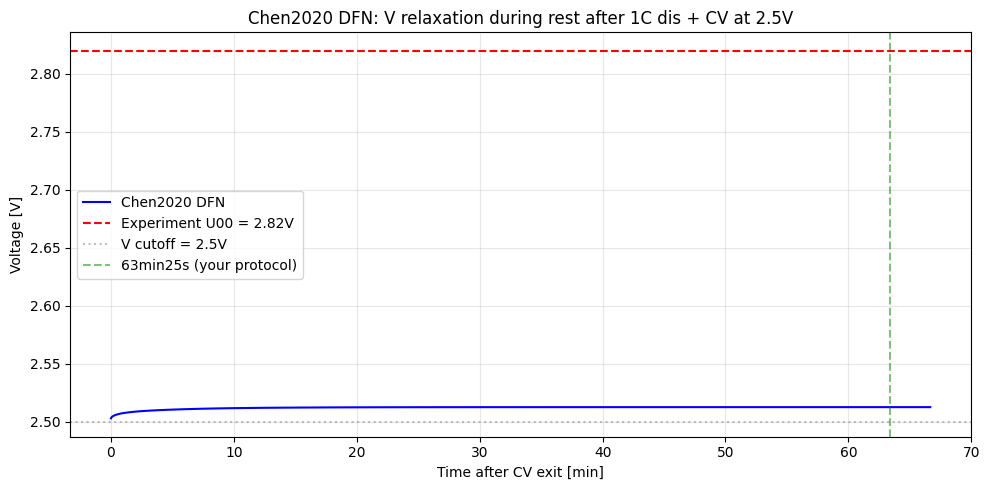

In [7]:
# X2/X4 Cell P1: Probe — V vs rest duration after CV at 2.5V (Chen2020 DFN)
import pybamm
import numpy as np
import matplotlib.pyplot as plt

probe_experiment = pybamm.Experiment([
    "Discharge at 1C until 2.5V",
    "Hold at 2.5V until C/136",
    "Rest for 60 seconds",        # we'll inspect V evolution
])

probe_model = pybamm.lithium_ion.DFN(options={"thermal": "lumped"})
probe_pv = pybamm.ParameterValues("Chen2020")
probe_pv["Ambient temperature [K]"] = 20.0 + 273.15
probe_pv["Initial temperature [K]"] = 20.0 + 273.15

probe_sim = pybamm.Simulation(probe_model, parameter_values=probe_pv, experiment=probe_experiment)
probe_sol = probe_sim.solve()

# Get the rest cycle (Cycle 2, index 2)
rest_cycle = probe_sol.cycles[2]
t_rest = rest_cycle.t - rest_cycle.t[0]    # relative time since rest start
V_rest = rest_cycle["Voltage [V]"].entries

print(f"Voltage during 60s rest after CV at 2.5V (Chen2020 DFN):")
print(f"{'t (s)':>8}  {'V (V)':>10}")
for t_target in [0, 1, 5, 10, 30, 60]:
    idx = np.argmin(np.abs(t_rest - t_target))
    print(f"{t_rest[idx]:>8.2f}  {V_rest[idx]:>10.4f}")

# Now extend rest to 4000s to see full relaxation curve
probe_experiment_long = pybamm.Experiment([
    "Discharge at 1C until 2.5V",
    "Hold at 2.5V until C/136",
    "Rest for 4000 seconds",
])
probe_sim_long = pybamm.Simulation(probe_model, parameter_values=probe_pv, experiment=probe_experiment_long)
probe_sol_long = probe_sim_long.solve()

rest_long = probe_sol_long.cycles[2]
t_long = rest_long.t - rest_long.t[0]
V_long = rest_long["Voltage [V]"].entries

print(f"\nFull 4000s rest curve:")
for t_target in [0, 60, 300, 600, 1000, 2000, 3000, 3805, 4000]:
    if t_target <= t_long.max():
        idx = np.argmin(np.abs(t_long - t_target))
        print(f"  t={t_long[idx]:.0f}s ({t_long[idx]/60:.1f}min):  V = {V_long[idx]:.4f}V")

# Find when V crosses 2.82V (target)
target_V = 2.82
above_target = np.where(V_long >= target_V)[0]
if len(above_target) > 0:
    t_at_282 = t_long[above_target[0]]
    print(f"\n*** V reaches 2.82V at t = {t_at_282:.1f}s ({t_at_282/60:.1f}min) of rest ***")
else:
    max_V = V_long.max()
    t_at_max = t_long[np.argmax(V_long)]
    print(f"\n⚠ V never reaches 2.82V. Max V = {max_V:.4f}V at t={t_at_max:.1f}s")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t_long/60, V_long, 'b-', linewidth=1.5, label="Chen2020 DFN")
ax.axhline(2.82, color='r', linestyle='--', label="Experiment U00 = 2.82V")
ax.axhline(2.5, color='gray', linestyle=':', alpha=0.5, label="V cutoff = 2.5V")
ax.axvline(63.4, color='g', linestyle='--', alpha=0.5, label="63min25s (your protocol)")
ax.set_xlabel("Time after CV exit [min]")
ax.set_ylabel("Voltage [V]")
ax.set_title("Chen2020 DFN: V relaxation during rest after 1C dis + CV at 2.5V")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# Cell P2: Probe — what V does set_initial_state give for various SOC?
import pybamm
import numpy as np

pv_test = pybamm.ParameterValues("Chen2020")
model_test = pybamm.lithium_ion.DFN(options={"thermal": "lumped"})

# Test multiple SOC values
print(f"{'SOC %':>8} {'V_init [V]':>12}")
print("-" * 22)
for soc in [0.00, 0.01, 0.02, 0.03, 0.04, 0.05, 0.07, 0.10]:
    pv = pybamm.ParameterValues("Chen2020")
    pv.set_initial_state(soc)
    sim = pybamm.Simulation(model_test, parameter_values=pv,
                            experiment=pybamm.Experiment(["Rest for 1 second"]))
    sol = sim.solve()
    V_init = float(sol["Voltage [V]"].entries[0])
    print(f"{soc*100:>7.1f}% {V_init:>12.4f}")

   SOC %   V_init [V]
----------------------
    0.0%       2.5000
    1.0%       2.7114
    2.0%       2.8625
    3.0%       2.9712
    4.0%       3.0504
    5.0%       3.1094
    7.0%       3.1933
   10.0%       3.2959


In [9]:
# Cell P3: Bisect search for SOC that gives V_init = 2.82V
import pybamm
import numpy as np

target_V = 2.82
soc_lo, soc_hi = 0.010, 0.020
model_bs = pybamm.lithium_ion.DFN(options={"thermal": "lumped"})

print(f"Bisecting SOC for V_init = {target_V} V...")
print(f"{'iter':>4} {'soc_lo':>8} {'soc_hi':>8} {'soc_mid':>9} {'V_mid':>10}")

for i in range(15):
    soc_mid = (soc_lo + soc_hi) / 2
    pv = pybamm.ParameterValues("Chen2020")
    pv.set_initial_state(soc_mid)
    sim = pybamm.Simulation(model_bs, parameter_values=pv,
                            experiment=pybamm.Experiment(["Rest for 1 second"]))
    sol = sim.solve()
    V_mid = float(sol["Voltage [V]"].entries[0])
    print(f"{i+1:>4} {soc_lo:>8.5f} {soc_hi:>8.5f} {soc_mid:>9.5f} {V_mid:>10.4f}")
    
    if abs(V_mid - target_V) < 0.002:
        break
    if V_mid < target_V:
        soc_lo = soc_mid
    else:
        soc_hi = soc_mid

print(f"\n*** Final: SOC = {soc_mid:.5f} → V_init = {V_mid:.4f}V ***")
print(f"Use this SOC value for all subsequent X2/X4 re-run batches.")

# Save for use
SOC_INIT_TARGET = soc_mid
print(f"\nSOC_INIT_TARGET = {SOC_INIT_TARGET:.5f}")

Bisecting SOC for V_init = 2.82 V...
iter   soc_lo   soc_hi   soc_mid      V_mid
   1  0.01000  0.02000   0.01500     2.7932
   2  0.01500  0.02000   0.01750     2.8293
   3  0.01500  0.01750   0.01625     2.8116
   4  0.01625  0.01750   0.01688     2.8206

*** Final: SOC = 0.01688 → V_init = 2.8206V ***
Use this SOC value for all subsequent X2/X4 re-run batches.

SOC_INIT_TARGET = 0.01688
